# SPARTAN all-site HIPS/FABS overview

A network-wide orientation notebook for the SPARTAN sites we have pulled. This is meant to show Anne the part she has **not** already seen repeatedly: the broader SPARTAN site inventory and HIPS/FABS coverage beyond the four-site FTIR analysis.

The notebook separates two things that are easy to mix up:

- **Public SPARTAN inventory:** 37 public sites and 9 public subproducts, mostly chemistry/nephelometer/time-resolved PM products.
- **HIPS/FABS bridge:** 27 sites with HIPS sample filters and FABS, plus blanks. This is the useful all-site view for absorption, but it is not all 37 public sites.


## 0. What this can and cannot answer

This notebook is for **coverage and site-to-site HIPS/FABS context**, not a final mechanism claim.

Important caveat: the public SPARTAN **BC PM2.5** product is derived from HIPS FABS using a network-wide MAC of about 10 m²/g. That means public BC and HIPS FABS are not independent measurements. Use this notebook to answer “which sites exist, which have FABS, how much data is there, and how different are the sites?” Do not use public BC to validate HIPS.


## 1. Setup


In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

REPO = Path('/Users/ahmadjalil/github/aethmodular')
INV = REPO / 'research' / 'spartan' / 'inventory'
OUT = REPO / 'research' / 'spartan' / 'all_sites_overview'
FIG = OUT / 'figures'
TAB = OUT / 'tables'
FIG.mkdir(parents=True, exist_ok=True)
TAB.mkdir(parents=True, exist_ok=True)

warnings.filterwarnings('ignore', category=RuntimeWarning)
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.edgecolor': '#333333',
    'axes.grid': True,
    'grid.alpha': 0.25,
    'font.size': 10,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
})

print(f'Outputs: {OUT.relative_to(REPO)}')


Outputs: research/spartan/all_sites_overview


## 2. Load the all-site inventory tables


In [2]:
overview = pd.read_csv(INV / 'overview.csv')
master = pd.read_csv(INV / 'master_connections.csv')
hips_cov = pd.read_csv(INV / 'hips_coverage_by_site.csv')
link = pd.read_csv(INV / 'hips_vs_public_link.csv')
site_locations = pd.read_csv(INV / 'site_locations.csv')

# Clean impossible date typo rows in public inventory summaries.
for col in ['date_min', 'date_max']:
    overview[col] = pd.to_datetime(overview[col], errors='coerce')
overview.loc[overview['date_max'].dt.year.gt(2030), 'date_max'] = pd.NaT

for col in ['date_min', 'date_max']:
    hips_cov[col] = pd.to_datetime(hips_cov[col], errors='coerce')
link['sample_date'] = pd.to_datetime(link['sample_date'], errors='coerce')

link['fabs_mean'] = pd.to_numeric(link['fabs_mean'], errors='coerce').replace([np.inf, -np.inf], np.nan)
link['bc_pm25'] = pd.to_numeric(link['bc_pm25'], errors='coerce')
link['pm25_mass'] = pd.to_numeric(link['pm25_mass'], errors='coerce')

print(f'Public inventory sites: {overview.site.nunique():,}')
print(f'HIPS/FABS sites: {hips_cov.Site.nunique():,}')
print(f'Master connection rows, including lookup-only/new sites: {len(master):,}')
print(f'HIPS-public filter bridge rows: {len(link):,}')
print('\nBridge presence counts:')
print(link['presence'].value_counts().to_string())


Public inventory sites: 37
HIPS/FABS sites: 27
Master connection rows, including lookup-only/new sites: 40
HIPS-public filter bridge rows: 4,818

Bridge presence counts:
presence
both          2522
right_only    1640
left_only      656


In [3]:
site_summary = master.copy()
public_rows = overview.groupby('site')['rows'].sum().rename('public_rows')
site_summary = site_summary.merge(public_rows, on='site', how='left')
site_summary['public_rows'] = site_summary['public_rows'].fillna(0).astype(int)
site_summary['has_hips_samples'] = site_summary['hips_sample_filters'].fillna(0).gt(0)
site_summary['status'] = np.select(
    [site_summary['in_public'] & site_summary['has_hips_samples'], site_summary['in_public'], site_summary['has_hips_samples']],
    ['public + HIPS', 'public only', 'HIPS only'],
    default='lookup only'
)
site_summary.to_csv(TAB / 'all_site_inventory_summary.csv', index=False)
display(
    site_summary
    .sort_values(['has_hips_samples', 'hips_sample_filters', 'public_rows'], ascending=[False, False, False])
    [['site', 'lookup_name', 'status', 'n_public_subproducts', 'public_rows', 'hips_sample_filters', 'hips_blank_filters']]
    .reset_index(drop=True)
)


,site,lookup_name,status,n_public_subproducts,public_rows,hips_sample_filters,hips_blank_filters
0,ETAD,"AddisAbaba, Ethiopia",public + HIPS,3,12233,239,41
1,ZAPR,"Pretoria, South Africa",public + HIPS,9,40958,214,42
2,ZAJB,"Johannesburg, South Africa",public + HIPS,3,10953,210,54
3,TWTA,"Taipei, Taiwan",public + HIPS,3,12925,205,51
4,CHTS,"Beijing, China",public + HIPS,9,84610,202,30
5,INDH,"Delhi, India",public + HIPS,2,4743,188,36
6,CLST,"Santiago, Chile",public + HIPS,2,7737,171,29
7,TWKA,"Kaohsiung, Taiwan",public + HIPS,3,8086,159,25
8,USPA,"Pasadena, UnitedStates",public + HIPS,2,13203,158,26
9,ILNZ,"Rehovot, Israel",public + HIPS,9,60366,154,22


## 3. Map: public network vs HIPS/FABS subset

This is the first “she has not seen this” plot: not just Beijing/Delhi/JPL/Addis, but the pulled SPARTAN network and which sites have HIPS/FABS data.


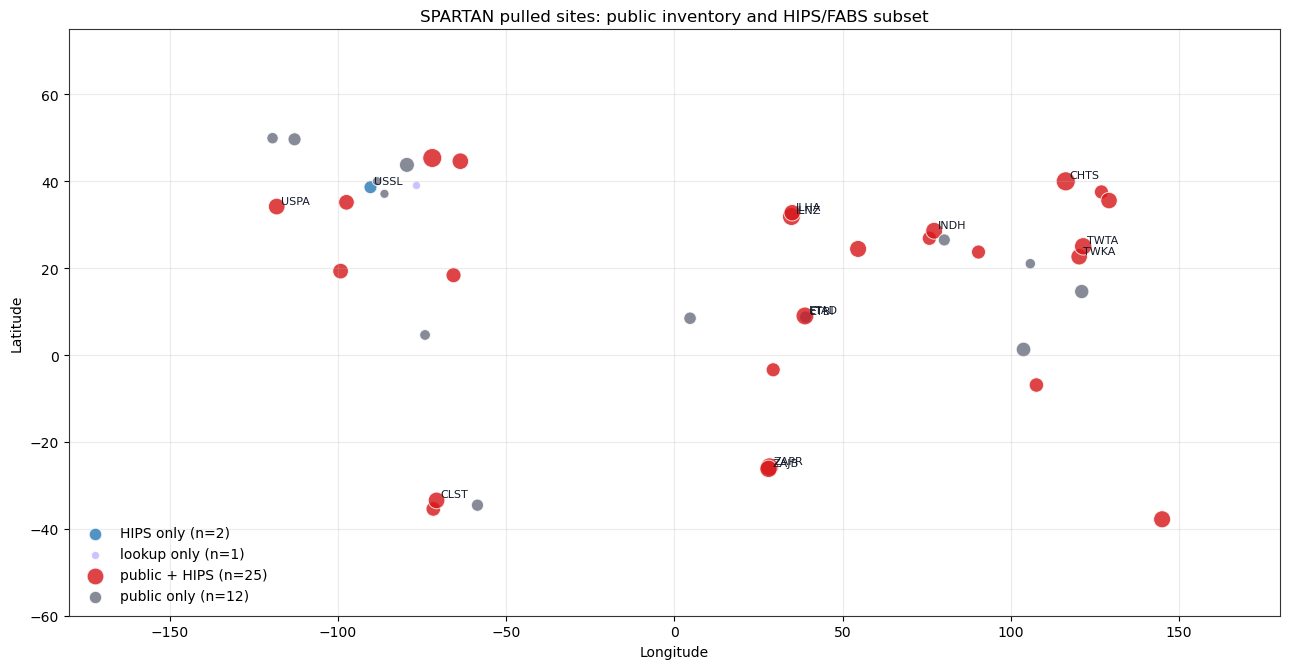

In [4]:
plot_sites = site_summary.copy()
plot_sites['lat'] = plot_sites['lookup_lat']
plot_sites['lon'] = plot_sites['lookup_lon']
missing = plot_sites['lat'].isna() | plot_sites['lon'].isna()
if missing.any():
    plot_sites = plot_sites.merge(site_locations.rename(columns={'lat': 'lat_public', 'lon': 'lon_public'}), on='site', how='left')
    plot_sites.loc[missing, 'lat'] = plot_sites.loc[missing, 'lat_public']
    plot_sites.loc[missing, 'lon'] = plot_sites.loc[missing, 'lon_public']

colors = {'public + HIPS': '#D7191C', 'public only': '#6B7280', 'HIPS only': '#2C7BB6', 'lookup only': '#C4B5FD'}
fig, ax = plt.subplots(figsize=(13, 6.8))
for status, g in plot_sites.dropna(subset=['lat', 'lon']).groupby('status'):
    size = 35 + np.sqrt(g['hips_sample_filters'].fillna(0) + g['public_rows'].fillna(0) / 500).clip(0, 60) * 8
    ax.scatter(g['lon'], g['lat'], s=size, c=colors.get(status, '0.5'), alpha=0.82, edgecolor='white', linewidth=0.7, label=f'{status} (n={len(g)})')
    for _, r in g.iterrows():
        if r['hips_sample_filters'] >= 150 or r['status'] == 'HIPS only':
            ax.text(r['lon'] + 1.2, r['lat'] + 0.7, r['site'], fontsize=8, color='#111827')
ax.set_xlim(-180, 180)
ax.set_ylim(-60, 75)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('SPARTAN pulled sites: public inventory and HIPS/FABS subset')
ax.legend(frameon=False, loc='lower left')
fig.tight_layout()
fig.savefig(FIG / 'fig01_spartan_all_sites_map.png', dpi=230, bbox_inches='tight')
plt.show()


## 4. Coverage: what sites have what?


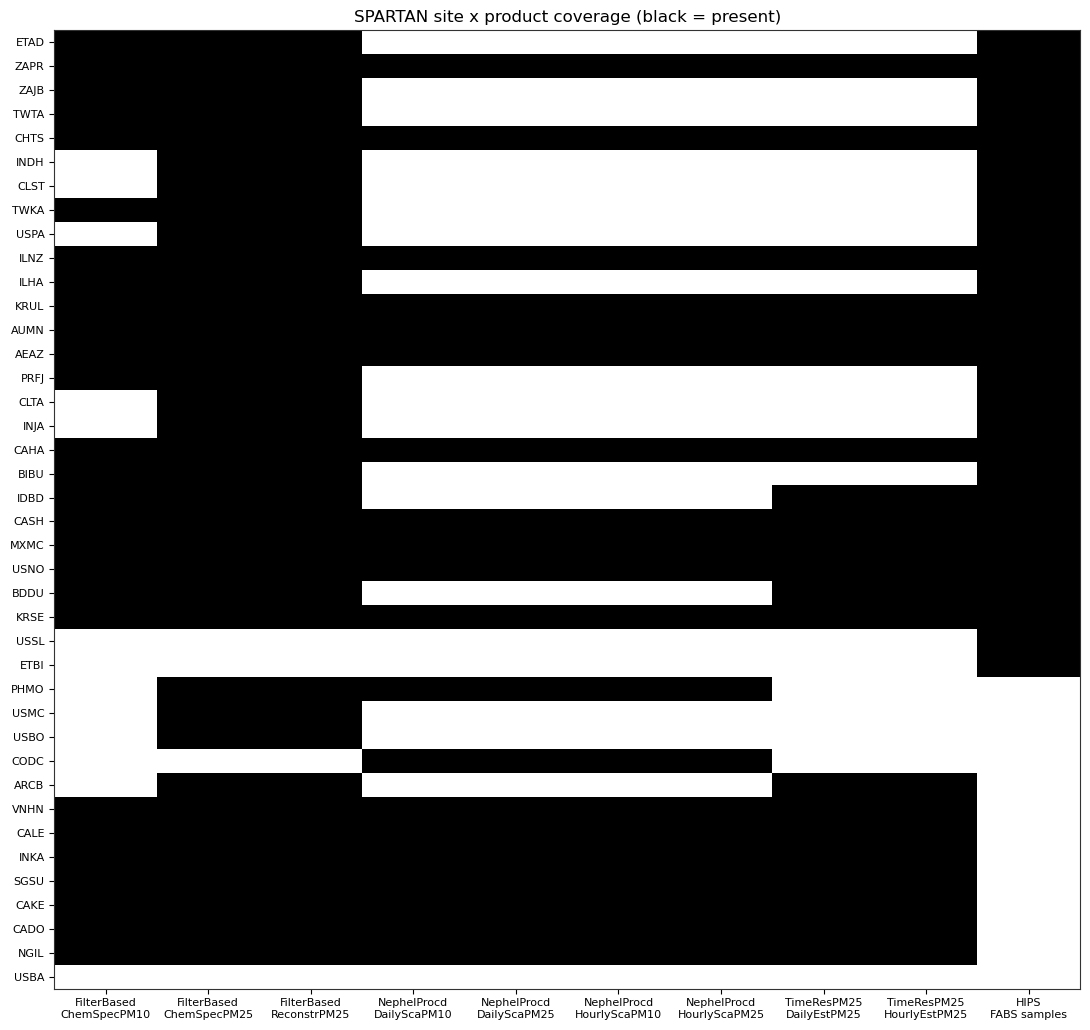

In [5]:
subproducts = [
    'FilterBased/ChemSpecPM10', 'FilterBased/ChemSpecPM25', 'FilterBased/ReconstrPM25',
    'NephelProcd/DailyScaPM10', 'NephelProcd/DailyScaPM25',
    'NephelProcd/HourlyScaPM10', 'NephelProcd/HourlyScaPM25',
    'TimeResPM25/DailyEstPM25', 'TimeResPM25/HourlyEstPM25',
]
coverage = site_summary[['site', 'hips_sample_filters'] + subproducts].copy().fillna(0)
coverage = coverage.sort_values('hips_sample_filters', ascending=False).set_index('site')
mat = coverage[subproducts].gt(0).astype(int)
mat['HIPS/FABS samples'] = coverage['hips_sample_filters'].gt(0).astype(int)

fig, ax = plt.subplots(figsize=(11, max(8, 0.26 * len(mat))))
ax.imshow(mat.values, aspect='auto', cmap=plt.cm.Greys, vmin=0, vmax=1)
ax.set_xticks(range(len(mat.columns)))
ax.set_xticklabels([c.replace('/', '\n') for c in mat.columns], rotation=0, ha='center', fontsize=8)
ax.set_yticks(range(len(mat.index)))
ax.set_yticklabels(mat.index, fontsize=8)
ax.set_title('SPARTAN site x product coverage (black = present)')
ax.grid(False)
fig.tight_layout()
fig.savefig(FIG / 'fig02_site_product_coverage_matrix.png', dpi=230, bbox_inches='tight')
plt.show()


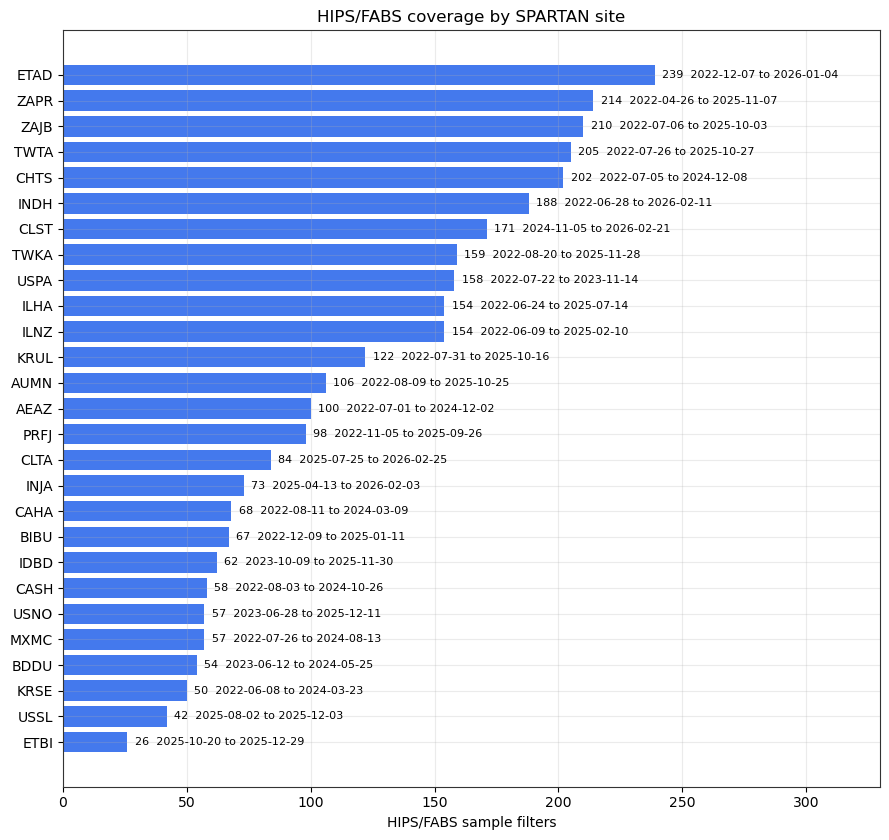

In [6]:
rank = hips_cov.sort_values('n_filters', ascending=True).copy()
fig, ax = plt.subplots(figsize=(9, 8.5))
ax.barh(rank['Site'], rank['n_filters'], color='#2563EB', alpha=0.86)
for _, r in rank.iterrows():
    ax.text(r['n_filters'] + 3, r['Site'], f"{int(r['n_filters'])}  {r['date_min'].date()} to {r['date_max'].date()}", va='center', fontsize=8)
ax.set_xlabel('HIPS/FABS sample filters')
ax.set_title('HIPS/FABS coverage by SPARTAN site')
ax.set_xlim(0, rank['n_filters'].max() * 1.38)
fig.tight_layout()
fig.savefig(FIG / 'fig03_hips_filters_by_site.png', dpi=230, bbox_inches='tight')
plt.show()


## 5. FABS distributions across all HIPS sites


In [7]:
fabs = link[link['fabs_mean'].notna() & np.isfinite(link['fabs_mean']) & link['fabs_mean'].gt(0)].copy()
site_stats = (
    fabs.groupby('site')['fabs_mean']
    .agg(n='count', median='median', mean='mean', p05=lambda s: s.quantile(.05), p95=lambda s: s.quantile(.95), max='max')
    .reset_index()
)
site_stats = site_stats.merge(hips_cov[['Site', 'mdl_median', 'pct_above_mdl']].rename(columns={'Site': 'site'}), on='site', how='left')
site_stats = site_stats.sort_values('median', ascending=False)
site_stats.to_csv(TAB / 'hips_fabs_site_distribution_stats.csv', index=False)
display(site_stats.round(2))


,site,n,median,mean,p05,p95,max,mdl_median,pct_above_mdl
15,INJA,71,50.03,53.62,23.69,81.58,129.38,3.14,97.26
14,INDH,152,49.42,63.27,8.52,145.96,225.52,3.17,79.26
9,ETAD,239,47.11,48.69,33.88,68.18,86.61,1.56,100.00
2,BDDU,54,38.68,46.67,31.65,82.56,94.19,1.57,100.00
3,BIBU,59,36.27,40.47,26.31,60.42,78.04,1.55,88.06
11,IDBD,54,29.47,29.99,16.65,41.37,55.75,1.57,87.10
0,AEAZ,89,28.93,30.08,14.92,45.01,108.11,1.57,89.00
10,ETBI,26,26.94,27.43,19.97,37.92,42.06,1.57,100.00
25,ZAJB,210,24.01,24.86,10.60,39.85,48.60,1.57,100.00
7,CLST,167,20.83,25.42,9.91,51.48,70.90,1.59,97.66


/var/folders/7k/65ckdzsj0w3171qv80rh8dgr0000gn/T/ipykernel_90509/661556327.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, vert=False, labels=order, showfliers=False, patch_artist=True)


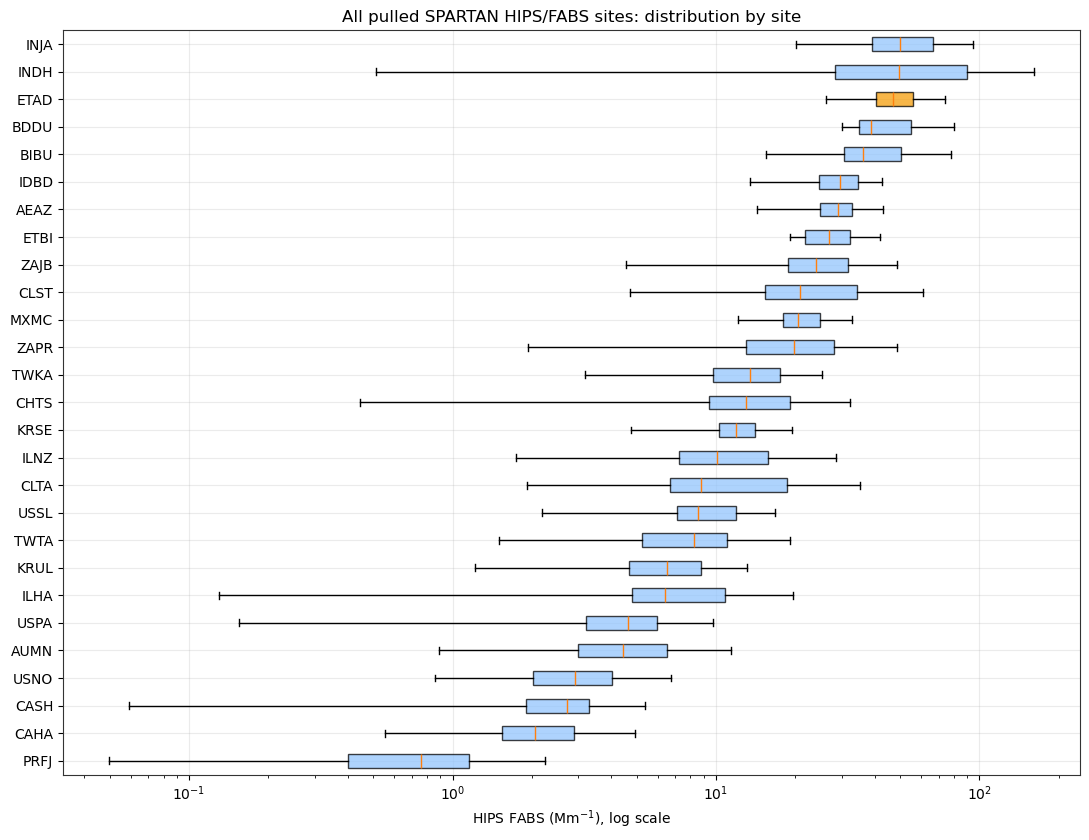

In [8]:
order = site_stats.sort_values('median')['site'].tolist()
box_data = [fabs.loc[fabs['site'].eq(site), 'fabs_mean'].dropna().values for site in order]

fig, ax = plt.subplots(figsize=(11, 8.5))
bp = ax.boxplot(box_data, vert=False, labels=order, showfliers=False, patch_artist=True)
for patch, site in zip(bp['boxes'], order):
    patch.set_facecolor('#F59E0B' if site == 'ETAD' else '#93C5FD')
    patch.set_alpha(0.75)
ax.set_xscale('log')
ax.set_xlabel('HIPS FABS (Mm$^{-1}$), log scale')
ax.set_title('All pulled SPARTAN HIPS/FABS sites: distribution by site')
fig.tight_layout()
fig.savefig(FIG / 'fig04_fabs_distribution_by_site.png', dpi=230, bbox_inches='tight')
plt.show()


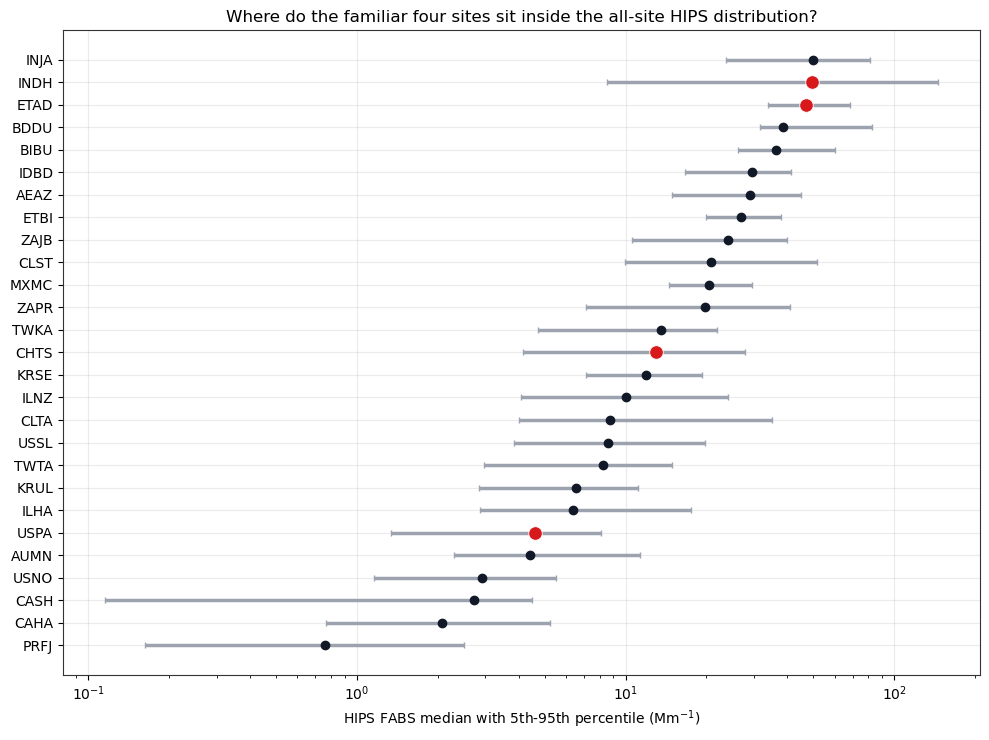

In [9]:
fig, ax = plt.subplots(figsize=(10, 7.5))
plot = site_stats.sort_values('median', ascending=True)
ax.errorbar(
    plot['median'], plot['site'],
    xerr=[plot['median'] - plot['p05'], plot['p95'] - plot['median']],
    fmt='o', color='#111827', ecolor='#9CA3AF', elinewidth=2.5, capsize=2,
)
for site in ['ETAD', 'INDH', 'USPA', 'CHTS']:
    if site in plot['site'].values:
        r = plot[plot['site'].eq(site)].iloc[0]
        ax.scatter(r['median'], r['site'], s=95, color='#D7191C', edgecolor='white', linewidth=0.6, zorder=3)
ax.set_xscale('log')
ax.set_xlabel('HIPS FABS median with 5th-95th percentile (Mm$^{-1}$)')
ax.set_title('Where do the familiar four sites sit inside the all-site HIPS distribution?')
fig.tight_layout()
fig.savefig(FIG / 'fig05_familiar_four_in_all_site_context.png', dpi=230, bbox_inches='tight')
plt.show()


## 6. Monthly coverage: when was HIPS/FABS collected?


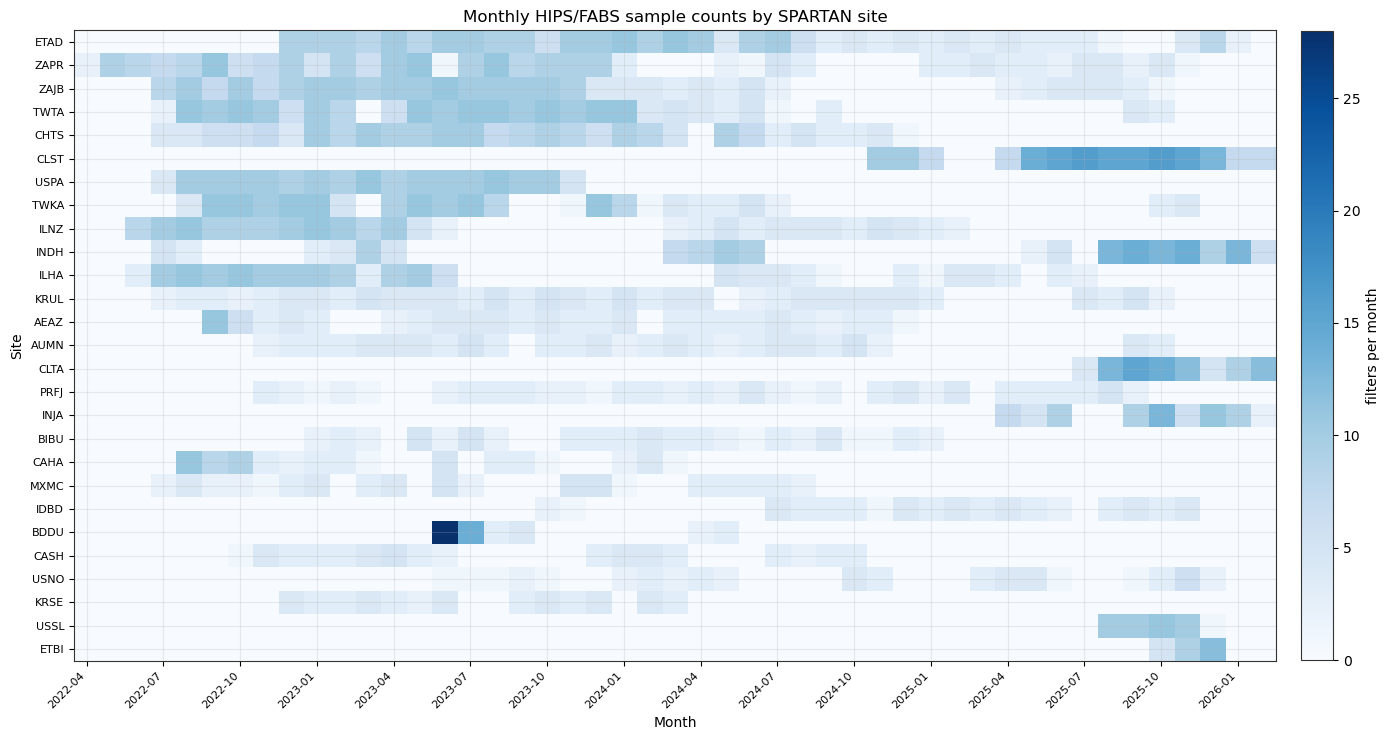

In [10]:
fabs_dates = fabs.dropna(subset=['sample_date']).copy()
fabs_dates['month'] = fabs_dates['sample_date'].dt.to_period('M').astype(str)
monthly = fabs_dates.groupby(['site', 'month']).size().rename('n').reset_index()
site_order = site_stats.sort_values('n', ascending=False)['site'].tolist()
month_order = sorted(monthly['month'].unique())
heat = monthly.pivot(index='site', columns='month', values='n').reindex(index=site_order, columns=month_order).fillna(0)
heat.to_csv(TAB / 'hips_fabs_monthly_counts.csv')

fig, ax = plt.subplots(figsize=(14, 7.5))
im = ax.imshow(heat.values, aspect='auto', cmap='Blues')
ax.set_yticks(range(len(heat.index)))
ax.set_yticklabels(heat.index, fontsize=8)
step = max(1, len(heat.columns) // 14)
ax.set_xticks(range(0, len(heat.columns), step))
ax.set_xticklabels(heat.columns[::step], rotation=45, ha='right', fontsize=8)
ax.set_title('Monthly HIPS/FABS sample counts by SPARTAN site')
ax.set_xlabel('Month')
ax.set_ylabel('Site')
fig.colorbar(im, ax=ax, label='filters per month', fraction=0.025, pad=0.02)
fig.tight_layout()
fig.savefig(FIG / 'fig06_hips_monthly_heatmap_all_sites.png', dpi=230, bbox_inches='tight')
plt.show()


## 7. HIPS FABS vs public BC bridge

This plot is useful as a data provenance slide, not as validation. For filters present in both the HIPS file and public SPARTAN product, public BC tracks FABS with a slope of about 10 because BC is calculated from FABS using MAC = 10 m²/g.


,site,n,slope_fabs_per_public_bc,intercept,r2
9,ETAD,232,9.989,0.161,0.999
23,ZAJB,202,9.972,0.037,1.000
20,TWTA,193,9.996,0.014,1.000
24,ZAPR,190,10.038,-0.047,1.000
6,CHTS,175,10.007,0.006,0.999
7,CLST,163,9.998,0.005,1.000
22,USPA,156,10.013,-0.016,0.999
19,TWKA,153,9.919,0.141,0.998
12,ILNZ,142,9.998,0.006,1.000
11,ILHA,137,10.002,-0.002,1.000


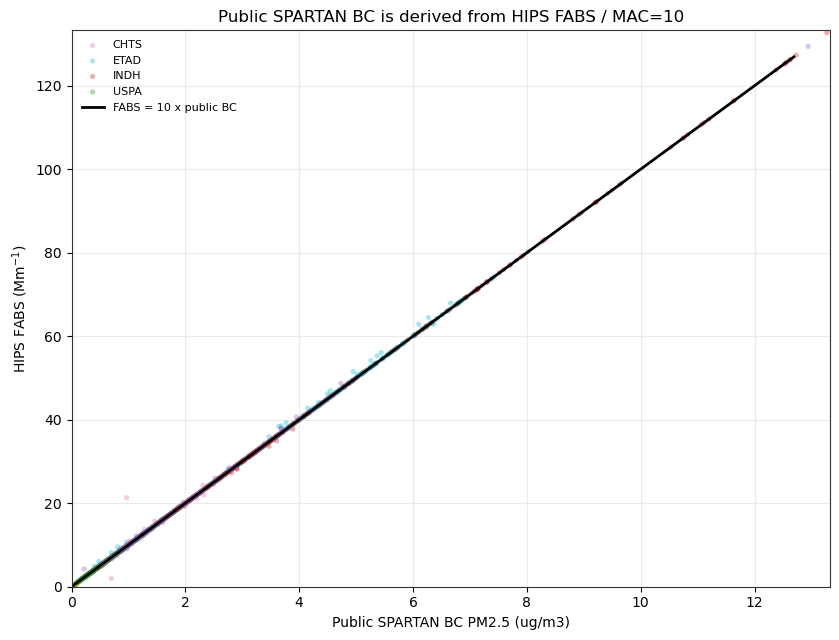

In [11]:
both = link[
    link['presence'].eq('both')
    & link['fabs_mean'].notna()
    & link['bc_pm25'].notna()
    & np.isfinite(link['fabs_mean'])
    & link['fabs_mean'].gt(0)
    & link['bc_pm25'].gt(0)
].copy()

fit_rows = []
for site, g in both.groupby('site'):
    if len(g) < 10:
        continue
    x = g['bc_pm25'].to_numpy(float)
    y = g['fabs_mean'].to_numpy(float)
    slope, intercept = np.polyfit(x, y, 1)
    pred = slope * x + intercept
    ss_res = ((y - pred) ** 2).sum()
    ss_tot = ((y - y.mean()) ** 2).sum()
    fit_rows.append({'site': site, 'n': len(g), 'slope_fabs_per_public_bc': slope, 'intercept': intercept, 'r2': 1 - ss_res / ss_tot if ss_tot else np.nan})
fits = pd.DataFrame(fit_rows).sort_values('n', ascending=False)
fits.to_csv(TAB / 'hips_fabs_vs_public_bc_site_fits.csv', index=False)
display(fits.round(3))

fig, ax = plt.subplots(figsize=(8.5, 6.5))
for site, g in both.groupby('site'):
    ax.scatter(g['bc_pm25'], g['fabs_mean'], s=14, alpha=0.38, edgecolor='none', label=site if site in ['ETAD', 'INDH', 'USPA', 'CHTS'] else None)
xline = np.linspace(0, both['bc_pm25'].quantile(.995), 200)
ax.plot(xline, 10 * xline, color='black', lw=2.0, label='FABS = 10 x public BC')
ax.set_xlim(0, both['bc_pm25'].quantile(.995) * 1.05)
ax.set_ylim(0, both['fabs_mean'].quantile(.995) * 1.05)
ax.set_xlabel('Public SPARTAN BC PM2.5 (ug/m3)')
ax.set_ylabel('HIPS FABS (Mm$^{-1}$)')
ax.set_title('Public SPARTAN BC is derived from HIPS FABS / MAC=10')
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
fig.savefig(FIG / 'fig07_hips_fabs_vs_public_bc_derivation.png', dpi=230, bbox_inches='tight')
plt.show()


## 8. Takeaways for Anne

- There are **37 public SPARTAN sites** in the local pull, but only **27 sites with HIPS/FABS sample filters** in the bridge file.
- The four familiar sites are not the whole story: ETAD/Addis is high, but several other sites have substantial FABS coverage and distinct distributions worth screening.
- Public SPARTAN BC is not independent of HIPS; it is effectively FABS divided by MAC=10. That is useful for provenance and consistency checks, but not for validating HIPS.
- The next useful step after this overview is to decide which non-four-site HIPS sites should be pulled into the IMPROVE EC-mass/FABS comparison once Mona/Alex provide clean EC/FABS fields.


In [12]:
print('Figures:')
for p in sorted(FIG.glob('*.png')):
    print(' ', p.relative_to(REPO))
print('\nTables:')
for p in sorted(TAB.glob('*.csv')):
    print(' ', p.relative_to(REPO))


Figures:
  research/spartan/all_sites_overview/figures/fig01_spartan_all_sites_map.png
  research/spartan/all_sites_overview/figures/fig02_site_product_coverage_matrix.png
  research/spartan/all_sites_overview/figures/fig03_hips_filters_by_site.png
  research/spartan/all_sites_overview/figures/fig04_fabs_distribution_by_site.png
  research/spartan/all_sites_overview/figures/fig05_familiar_four_in_all_site_context.png
  research/spartan/all_sites_overview/figures/fig06_hips_monthly_heatmap_all_sites.png
  research/spartan/all_sites_overview/figures/fig07_hips_fabs_vs_public_bc_derivation.png

Tables:
  research/spartan/all_sites_overview/tables/all_site_inventory_summary.csv
  research/spartan/all_sites_overview/tables/hips_fabs_monthly_counts.csv
  research/spartan/all_sites_overview/tables/hips_fabs_site_distribution_stats.csv
  research/spartan/all_sites_overview/tables/hips_fabs_vs_public_bc_site_fits.csv
